In [1]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

⏳ Merging 11 files from Label 0 directory, 9 files from Label 1 directory...

✅ All data has been successfully merged and saved as '../02_Processed_Data/06_Training_Data.csv'.

📊 TRAINING DATASET SUMMARY (TRAINING DATA)
Total Number of Rows (Windows) : 25,307
Total Number of Files (Experiments)   : 20
---------------------------------------------
Class Distribution (Row Count):
  🟢 NO Chatter (0) : 17,647 rows
  🔴 WITH Chatter (1) : 7,660 rows
---------------------------------------------
Class Distribution (Percentage):
  🟢 NO Chatter (0) : % 69.73
  🔴 WITH Chatter (1) : % 30.27


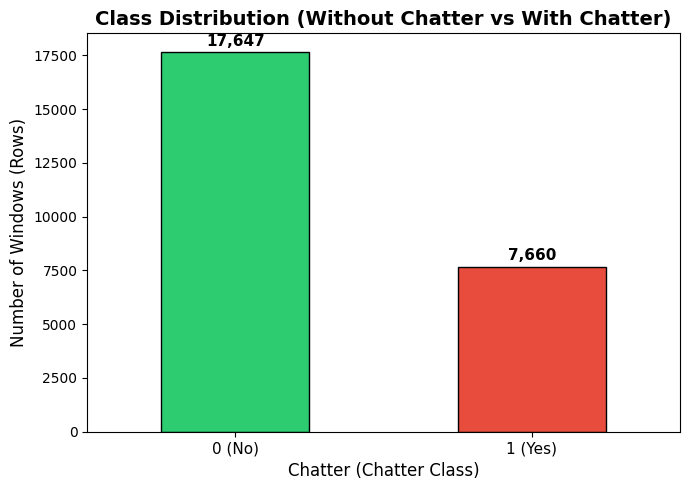

In [2]:


# --- 1. DETERMINING FILE PATHS ---
dir_label_0 = "../02_Processed_Data/04_Label_0"
dir_label_1 = "../02_Processed_Data/05_Label_1"
output_csv_path = "../02_Processed_Data/06_Training_Data.csv"

# --- 2. FINDING AND READING FILES ---
files_0 = glob.glob(os.path.join(dir_label_0, "*.csv"))
files_1 = glob.glob(os.path.join(dir_label_1, "*.csv"))
all_files = files_0 + files_1

print(f"⏳ Merging {len(files_0)} files from Label 0 directory, {len(files_1)} files from Label 1 directory...\n")

df_list = []
for f in all_files:
    df_list.append(pd.read_csv(f))

# --- 3. MERGING AND SAVING ---
# Merging all files row by row
df_train = pd.concat(df_list, ignore_index=True)

# Clean up empty or useless rows as a precaution
df_train = df_train.dropna(subset=['chatter']).reset_index(drop=True)

# Saving the final dataset we will use to train the model
df_train.to_csv(output_csv_path, index=False)
print(f"✅ All data has been successfully merged and saved as '{output_csv_path}'.\n")

# --- 4. DATASET SUMMARY (EDA - Exploratory Data Analysis) ---
total_rows = len(df_train)
unique_files = df_train['File_ID'].nunique()

# Chatter class counts and percentages
class_counts = df_train['chatter'].value_counts()
class_percentages = df_train['chatter'].value_counts(normalize=True) * 100

print("="*45)
print("📊 TRAINING DATASET SUMMARY (TRAINING DATA)")
print("="*45)
print(f"Total Number of Rows (Windows) : {total_rows:,}")
print(f"Total Number of Files (Experiments)   : {unique_files}")
print("-" * 45)
print("Class Distribution (Row Count):")
print(f"  🟢 NO Chatter (0) : {class_counts.get(0, 0):,} rows")
print(f"  🔴 WITH Chatter (1) : {class_counts.get(1, 0):,} rows")
print("-" * 45)
print("Class Distribution (Percentage):")
print(f"  🟢 NO Chatter (0) : % {class_percentages.get(0, 0):.2f}")
print(f"  🔴 WITH Chatter (1) : % {class_percentages.get(1, 0):.2f}")
print("="*45)

# --- 5. VISUALIZATION ---
plt.figure(figsize=(7, 5))
ax = class_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')

plt.title("Class Distribution (Without Chatter vs With Chatter)", fontsize=14, fontweight='bold')
plt.xlabel("Chatter (Chatter Class)", fontsize=12)
plt.ylabel("Number of Windows (Rows)", fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0 (No)', '1 (Yes)'], rotation=0, fontsize=11)

# Print values on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), ','), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 8), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()